# FFT Operation for Pink Noise

This notebook is a step-by-step, publication-style walkthrough of how the project's
**baseline pink noise** is built from 2D white noise via the 2D FFT.

**Scope of this notebook**

- Only the baseline pink-noise construction is covered here (no same-phase floor,
  no independent-white replenishment -- see `samePhase_vs_indiWhite_noise/noise_init.ipynb`
  for those).
- Nothing in `noise_init/noise_methods.py` is modified. The math below is written
  **inline** (not imported) so it can be read end-to-end, but it is checked for exact
  numerical equivalence against `noise_methods.radial_frequency_grid` / `pink_filter` /
  `pink` in the first code cell.
- Example: a single-channel, fixed-seed, $128\times128$ white-noise field
  (same resolution as `white_vs_pink_noise/noise_init.ipynb`).
- Default filter strength $\alpha=0.5$, with $\alpha=0$ (pure white noise) shown
  throughout as a control.

**Definitions used below** (using DivGen-compatible integer FFT-bin units):

$$f_y = \operatorname{fftfreq}(H)\cdot H, \qquad f_x = \operatorname{rfftfreq}(W)\cdot W$$

$$r(f_x,f_y) = \sqrt{f_x^2+f_y^2}, \qquad h(r) = (1+r)^{-\alpha}$$

$$z_{\text{pink}} = \mathrm{IFFT}_{2D}\big(\mathrm{FFT}_{2D}(z_{\text{white}})\cdot h(r)\big)$$

The generation order matches the order in which these quantities actually appear
in the code: 

Spatial white noise $\to$ Its 2D spectrum $\to$ The radius grid $r$ $\to$
The filter $h(r)$ $\to$ The filtered spectrum and its inverse transform $\to$ A radial power-spectrum summary connecting all preceding steps.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (registers the 3d projection)

SEED = 42
H, W = 128, 128        # spatial resolution (matches noise_init.ipynb's H=W=128)
C = 3                  # 3 channels sampled only for a vivid RGB-composite display,
                       # matching white_vs_pink_noise/noise_init.ipynb's style;
                       # every FFT/radius/PSD figure below still walks through a
                       # single representative channel, as originally scoped.
ALPHA = 0.5            # default pink-noise strength shown in this notebook
ALPHA_CONTROL = 0.0    # white-noise control (alpha=0 is an exact bypass, see below)

torch.manual_seed(0)   # local RNG for the equivalence check only


# --- Inline math -----------------------------------------------------------
# Mirrors noise_init/noise_methods.py exactly (radial_frequency_grid, pink_filter,
# pink). Written inline here so the whole derivation is readable in one place;
# verified bit-for-bit equivalent to the real implementation just below.

def radial_frequency_grid(height, width):
    fy = torch.fft.fftfreq(height) * height
    fx = torch.fft.rfftfreq(width) * width
    fy = fy.view(height, 1)
    fx = fx.view(1, width // 2 + 1)
    r = torch.sqrt(fy.square() + fx.square())
    return fy, fx, r


def pink_filter(height, width, alpha):
    _, _, r = radial_frequency_grid(height, width)
    return (1.0 + r).pow(-float(alpha))


def pink_noise(z_white, alpha):
    if alpha == 0.0:
        return z_white.clone()  # exact bypass: no FFT round trip needed
    height, width = z_white.shape[-2:]
    filt = pink_filter(height, width, alpha)
    z_hat = torch.fft.rfft2(z_white, dim=(-2, -1))
    return torch.fft.irfft2(z_hat * filt, s=(height, width), dim=(-2, -1))


def normalize2d(x, unbiased=False, eps=1e-8):
    flat = x.reshape(-1)
    out = (flat - flat.mean()) / (flat.std(unbiased=unbiased) + eps)
    return out.reshape_as(x)


def to_rgb_display(tensor_chw, lo, hi):
    """Clip the first 3 channels to a shared [lo, hi] range and rescale to [0, 1].

    Matches white_vs_pink_noise/noise_init.ipynb's to_rgb_display exactly, so the
    spatial-noise panels here read the same way (a 3-channel noise draw shown as
    an RGB composite, purely for visual style -- not a claim about color channels
    in an actual image).
    """
    img = tensor_chw[:3].detach().numpy().transpose(1, 2, 0)
    return np.clip((img - lo) / (hi - lo + 1e-8), 0, 1)


# --- Equivalence check against the real implementation ---------------------
import sys
sys.path.insert(0, "../noise_init")
from noise_methods import pink as real_pink, pink_filter as real_pink_filter

z_check = torch.randn(H, W)
for alpha_check in [0.0, 0.3, 0.9, 1.5]:
    mine = pink_noise(z_check, alpha_check)
    real = real_pink(z_check.view(1, 1, H, W), alpha_check).view(H, W)
    max_diff = (mine - real).abs().max().item()
    assert max_diff < 1e-5, f"mismatch at alpha={alpha_check}: {max_diff}"
assert torch.allclose(pink_filter(H, W, ALPHA), real_pink_filter(H, W, ALPHA), atol=1e-6)
print("Inline math verified equivalent to noise_init/noise_methods.py (max diff < 1e-5).")


# --- Sample the example noise field -----------------------------------------
# base_white_rgb holds 3 independent channels (one draw call, C=3) purely for the
# vivid RGB-composite spatial figures; base_white (channel 0) is the single 2D
# field every FFT/radius/PSD figure below actually walks through.
base_white_rgb = torch.randn(C, H, W, generator=torch.Generator("cpu").manual_seed(SEED))
base_white = base_white_rgb[0]
z_pink_rgb = pink_noise(base_white_rgb, ALPHA)
z_pink = pink_noise(base_white, ALPHA)
assert torch.equal(z_pink, z_pink_rgb[0])  # per-channel filtering is independent, so these must match exactly
z_white_control = pink_noise(base_white, ALPHA_CONTROL)  # identical to base_white by construction
assert torch.equal(z_white_control, base_white)
print(f"base_white shape={tuple(base_white.shape)} (channel 0 of {tuple(base_white_rgb.shape)}), alpha={ALPHA} (control alpha={ALPHA_CONTROL})")

Inline math verified equivalent to noise_init/noise_methods.py (max diff < 1e-5).
base_white shape=(128, 128) (channel 0 of (3, 128, 128)), alpha=0.5 (control alpha=0.0)


## Figure 1 -- Spatial white noise $z_{\text{white}}(x,y)$

This is the raw material: i.i.d. Gaussian noise with no spatial structure. By
convention in this project, the **row index is $y$ (height)** and the **column
index is $x$ (width)** -- i.e. the tensor is indexed `noise[y, x]`. Every later
figure keeps this same $(x,y)$ meaning for the spatial domain.

Displayed as an RGB composite of 3 independently-drawn channels (same style as
`white_vs_pink_noise/noise_init.ipynb`), purely so the spatial panels read the
same way across notebooks -- the FFT/radius/PSD figures that follow all walk
through a single representative channel (channel 0), matching the single-channel
scope of this notebook.

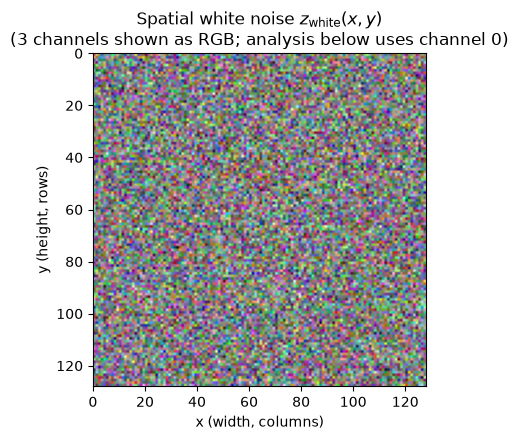

In [2]:
raw_lo, raw_hi = np.percentile(base_white_rgb.numpy(), 1), np.percentile(base_white_rgb.numpy(), 99)

fig, ax = plt.subplots(figsize=(5, 4.5))
ax.imshow(to_rgb_display(base_white_rgb, raw_lo, raw_hi), extent=[0, W, H, 0])
ax.set_xlabel("x (width, columns)")
ax.set_ylabel("y (height, rows)")
ax.set_title("Spatial white noise $z_{\\mathrm{white}}(x,y)$\n(3 channels shown as RGB; analysis below uses channel 0)")
fig.tight_layout()
plt.show()

## Figure 2 -- The 2D frequency grid $(f_x, f_y)$ after `rfft2`

`torch.fft.rfft2` transforms the **whole** $128\times128$ image into the **whole**
spectrum in one step -- it is not a per-pixel mapping, so there is no meaningful
arrow from "this pixel" to "this frequency point". Two axis-convention details
matter for reading the plot below:

- Because the input is real-valued, `rfft2` only stores the non-negative half of
  $f_x$ (the redundant, complex-conjugate half is dropped) -- hence $f_x \geq 0$.
- $f_y$ keeps the full range but comes out of `fftfreq` in *wrap-around* order
  ($0,1,\dots,31,-32,\dots,-1$). We reorder it (`fftshift`) purely for display, so
  that $f_y$ increases from negative to positive **top to bottom is not implied --
  we plot with $f_y$ ascending bottom to top**, putting the DC term $(f_x,f_y)=(0,0)$
  at the left-middle of the plot.

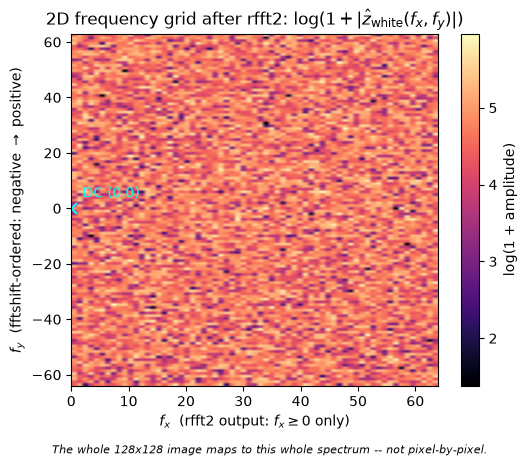

In [3]:
z_white_hat = torch.fft.rfft2(base_white)
fy_full = torch.fft.fftfreq(H) * H
fx_full = torch.fft.rfftfreq(W) * W
fy_shifted = torch.fft.fftshift(fy_full)
mag_shifted = torch.fft.fftshift(z_white_hat.abs(), dim=0)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
extent = [fx_full.min().item(), fx_full.max().item(), fy_shifted.min().item(), fy_shifted.max().item()]
im = ax.imshow(np.log1p(mag_shifted.numpy()), origin="lower", extent=extent, cmap="magma", aspect="auto")
ax.scatter([0], [0], marker="x", color="cyan", s=60)
ax.annotate("DC (0,0)", (0, 0), textcoords="offset points", xytext=(8, 8), color="cyan")
ax.set_xlabel("$f_x$  (rfft2 output: $f_x \\geq 0$ only)")
ax.set_ylabel("$f_y$  (fftshift-ordered: negative $\\to$ positive)")
ax.set_title("2D frequency grid after rfft2: $\\log(1+|\\hat{z}_{\\mathrm{white}}(f_x,f_y)|)$")
fig.colorbar(im, ax=ax, label="log(1 + amplitude)")
fig.text(0.5, -0.02, f"The whole {H}x{W} image maps to this whole spectrum -- not pixel-by-pixel.",
         ha="center", fontsize=8, style="italic")
fig.tight_layout()
plt.show()

## Figure 3 -- The radius $r(f_x,f_y)$: a truncated half-cone

$r=\sqrt{f_x^2+f_y^2}$ is **not** a spatial amplitude --
it grows *linearly* with distance from the origin, which is why the surface below
is a cone, not a dome. It is truncated because $f_x$ only ranges over
$[0, W/2]$ (the rfft2 half-spectrum) while $f_y$ ranges over the full
$[-H/2, H/2)$.

A useful sanity check for reading iso-radius contours: many different
$(f_x,f_y)$ pairs share the same $r$. For example $(f_x,f_y)=(5,0)$ and $(3,4)$
both give $r=\sqrt{25}=\sqrt{9+16}=5$ -- both points are marked below, sitting on
the same contour ring.

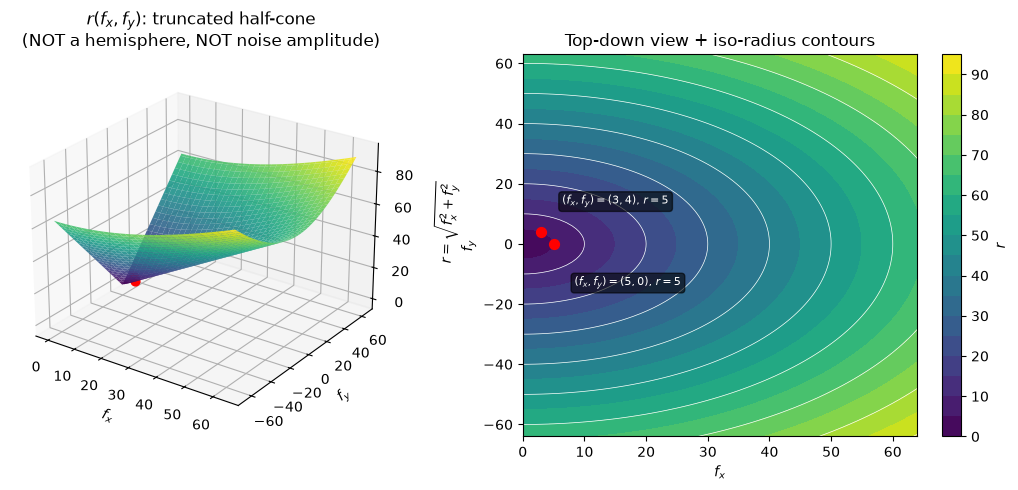

In [4]:
fy_shifted_np = fy_shifted.numpy()
fx_np = fx_full.numpy()
FX, FY = np.meshgrid(fx_np, fy_shifted_np)
R = np.sqrt(FX ** 2 + FY ** 2)
points = [(5, 0), (3, 4)]  # both satisfy r = 5

fig = plt.figure(figsize=(11, 5))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.plot_surface(FX, FY, R, cmap="viridis", linewidth=0, antialiased=True, alpha=0.9)
for px, py in points:
    r_val = np.sqrt(px ** 2 + py ** 2)
    ax1.scatter([px], [py], [r_val], color="red", s=40, depthshade=False)
ax1.set_xlabel("$f_x$"); ax1.set_ylabel("$f_y$")
ax1.set_zlabel("$r=\\sqrt{f_x^2+f_y^2}$", labelpad=10)
ax1.set_title("$r(f_x,f_y)$: truncated half-cone\n(NOT a hemisphere, NOT noise amplitude)")
ax1.view_init(elev=25, azim=-55)

ax2 = fig.add_subplot(1, 2, 2)
cf = ax2.contourf(FX, FY, R, levels=20, cmap="viridis")
ax2.contour(FX, FY, R, levels=10, colors="white", linewidths=0.5)
offsets = [(15, -30), (15, 20)]
for (px, py), offset in zip(points, offsets):
    r_val = np.sqrt(px ** 2 + py ** 2)
    ax2.scatter([px], [py], color="red", s=50, zorder=5)
    ax2.annotate(f"$(f_x,f_y)=({px},{py})$, $r={r_val:.0f}$", (px, py),
                 textcoords="offset points", xytext=offset, color="white", fontsize=8,
                 bbox=dict(boxstyle="round", fc="black", alpha=0.6))
ax2.set_xlabel("$f_x$"); ax2.set_ylabel("$f_y$")
ax2.set_title("Top-down view + iso-radius contours")
fig.colorbar(cf, ax=ax2, label="$r$")
fig.tight_layout()
plt.show()

## Figure 4 -- The filter $h(r)=(1+r)^{-\alpha}$ next to $r$ itself

Placed side by side: $r$ **increases** outward from the origin, while
$h(r)$ **decreases** outward -- it is a low-pass weight. Two frequency points with
the same $r$ (regardless of direction) always get the same filter weight, which is
exactly why $h$ is a function of $r$ alone and not of $f_x,f_y$ separately.

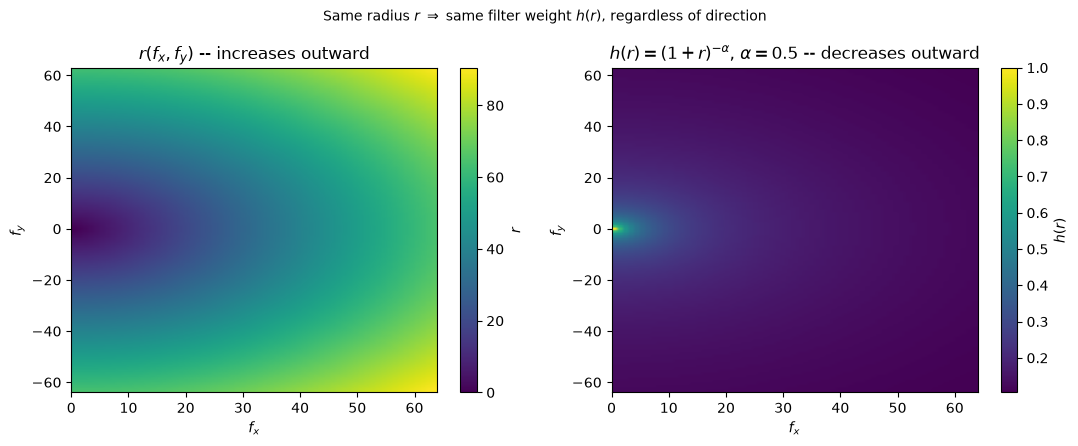

In [5]:
H_alpha = (1.0 + R) ** (-ALPHA)
extent = [fx_np.min(), fx_np.max(), fy_shifted_np.min(), fy_shifted_np.max()]

fig, (axr, axh) = plt.subplots(1, 2, figsize=(11, 4.5))
im_r = axr.imshow(R, origin="lower", extent=extent, cmap="viridis", aspect="auto")
axr.set_title("$r(f_x,f_y)$ -- increases outward")
axr.set_xlabel("$f_x$"); axr.set_ylabel("$f_y$")
fig.colorbar(im_r, ax=axr, label="$r$")

im_h = axh.imshow(H_alpha, origin="lower", extent=extent, cmap="viridis", aspect="auto")
axh.set_title(f"$h(r)=(1+r)^{{-\\alpha}}$, $\\alpha={ALPHA}$ -- decreases outward")
axh.set_xlabel("$f_x$"); axh.set_ylabel("$f_y$")
fig.colorbar(im_h, ax=axh, label="$h(r)$")

fig.suptitle("Same radius $r$ $\\Rightarrow$ same filter weight $h(r)$, regardless of direction", fontsize=10)
fig.tight_layout()
plt.show()

## Figure 5 -- Spectra before/after filtering, and the resulting spatial pink noise

Left and middle panels show **FFT amplitude** $|\hat{z}|$ (not power $|\hat{z}|^2$),
on a **shared** color scale so the low-pass effect of $h(r)$ is directly
comparable: the pink spectrum concentrates near the origin (low frequencies)
while the white spectrum is flat. These are single-channel scalar fields (one
FFT magnitude per frequency bin), so they stay on a scientific sequential
colormap rather than an RGB composite.

The right panel is a different quantity entirely -- the spatial-domain result
$z_{\text{pink}}(x,y)$ -- shown as the same 3-channel RGB composite as Figure 1
(own clip range), so the "fine static -> smooth blobs" effect of the filter is
visually obvious.

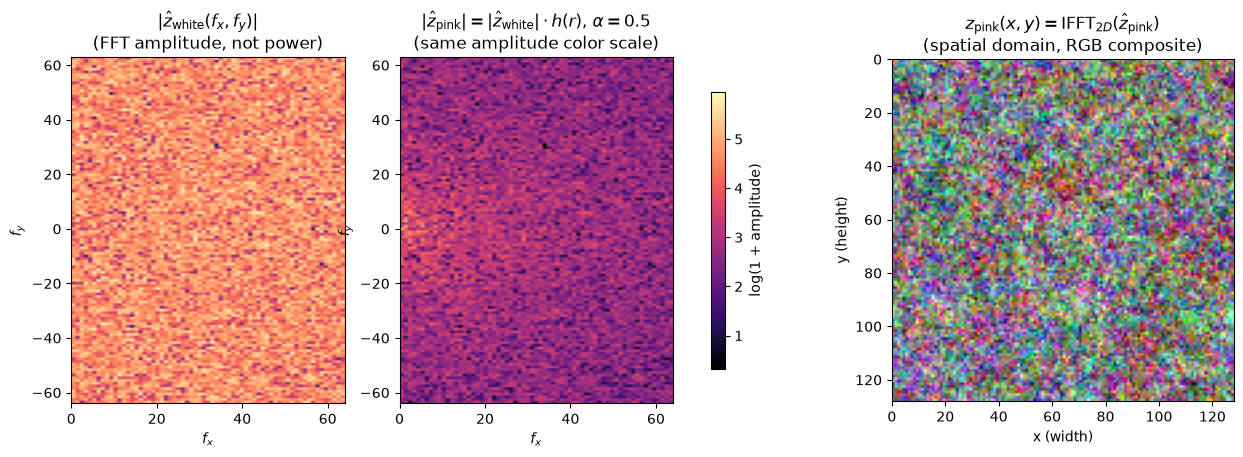

In [6]:
z_white_hat = torch.fft.rfft2(base_white)
z_pink_hat = torch.fft.rfft2(z_pink)
mag_white = torch.fft.fftshift(z_white_hat.abs(), dim=0).numpy()
mag_pink = torch.fft.fftshift(z_pink_hat.abs(), dim=0).numpy()
log_white, log_pink = np.log1p(mag_white), np.log1p(mag_pink)
vmin, vmax = min(log_white.min(), log_pink.min()), max(log_white.max(), log_pink.max())

fy_full = torch.fft.fftfreq(H) * H
fx_full = torch.fft.rfftfreq(W) * W
fy_shifted = torch.fft.fftshift(fy_full)
extent = [fx_full.min().item(), fx_full.max().item(), fy_shifted.min().item(), fy_shifted.max().item()]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].imshow(log_white, origin="lower", extent=extent, cmap="magma", vmin=vmin, vmax=vmax, aspect="auto")
axes[0].set_title("$|\\hat{z}_{\\mathrm{white}}(f_x,f_y)|$\n(FFT amplitude, not power)")
axes[0].set_xlabel("$f_x$"); axes[0].set_ylabel("$f_y$")

im1 = axes[1].imshow(log_pink, origin="lower", extent=extent, cmap="magma", vmin=vmin, vmax=vmax, aspect="auto")
axes[1].set_title(f"$|\\hat{{z}}_{{\\mathrm{{pink}}}}| = |\\hat{{z}}_{{\\mathrm{{white}}}}|\\cdot h(r)$, $\\alpha={ALPHA}$\n(same amplitude color scale)")
axes[1].set_xlabel("$f_x$"); axes[1].set_ylabel("$f_y$")
fig.colorbar(im1, ax=axes[:2].tolist(), label="log(1 + amplitude)", shrink=0.8)

pink_lo, pink_hi = np.percentile(z_pink_rgb.numpy(), 1), np.percentile(z_pink_rgb.numpy(), 99)
axes[2].imshow(to_rgb_display(z_pink_rgb, pink_lo, pink_hi), extent=[0, W, H, 0])
axes[2].set_title("$z_{\\mathrm{pink}}(x,y) = \\mathrm{IFFT}_{2D}(\\hat{z}_{\\mathrm{pink}})$\n(spatial domain, RGB composite)")
axes[2].set_xlabel("x (width)"); axes[2].set_ylabel("y (height)")
plt.show()

## Figure 6 -- Radially-averaged power spectrum: white vs. pink

The x-axis here is a **radial bin index**, not a spatial pixel coordinate and not
a count of 2D FFT grid points. Each bin groups together every $(f_x,f_y)$ pair
that shares the same rounded radius $r$ -- for a $128\times128$ field there are only
about $\sqrt{(H/2)^2+(W/2)^2}\approx91$ such bins, versus $128\times128=16384$ raw 2D
frequency-grid points that feed into them.

The theoretical pink power shape is $(1+r)^{-2\alpha}$ (power is the *square* of
the amplitude filter $h(r)$); the white control is flat. Both empirical curves and
the theoretical curve are rescaled to match at the first non-DC bin ($P(r)/P(1)$),
purely to compare *shapes* on one axis.

**Left panel** uses the raw (pre-normalization) $z_{\text{pink}}$ from Figure 5 --
this is what matches the $(1+r)^{-2\alpha}$ theory directly. **Right panel** uses
the same fields after the project's actual per-sample zero-mean/unit-std
normalization (`normalize`, `unbiased=False`). Since both panels are already
rescaled to $P(1)$, the two are directly comparable in shape -- and normalizing
barely changes that shape at all (see the shape-correlation check below), which is
the point of showing both.

128x128 field -> 16384 2D FFT grid points, but only 92 radial bins (max bin r=91).


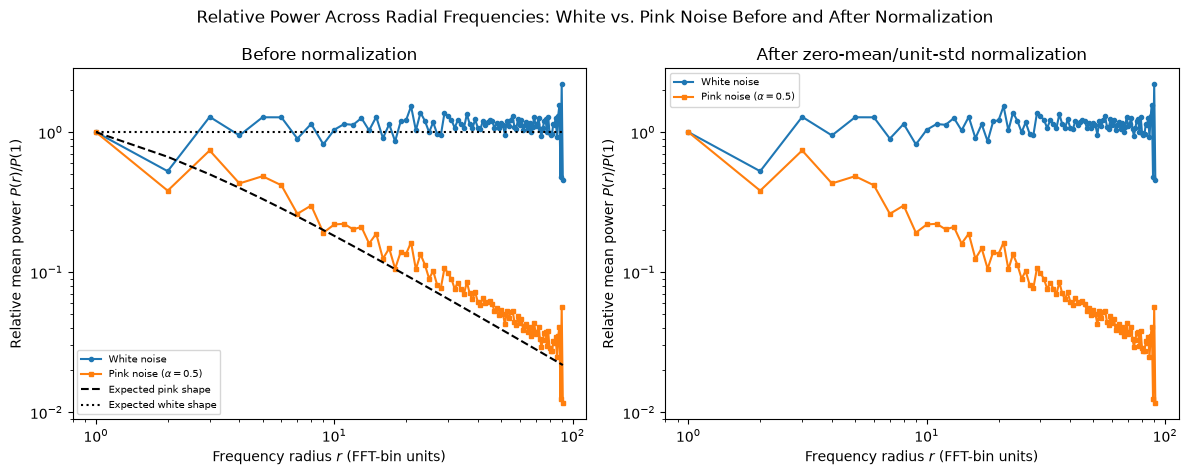

log-log shape correlation (pre vs post normalization, pink, excl. DC): 1.0000


In [7]:
fy_full_np = fy_full.numpy()
fx_full_full_np = (torch.fft.fftfreq(W) * W).numpy()  # full (non-rfft) range, for a clean symmetric bin count
FX2, FY2 = np.meshgrid(fx_full_full_np, fy_full_np)
R2 = np.sqrt(FX2 ** 2 + FY2 ** 2)
r_int = np.rint(R2).astype(int)
num_bins = r_int.max() + 1
print(f"{H}x{W} field -> {H*W} 2D FFT grid points, but only {num_bins} radial bins (max bin r={r_int.max()}).")

def radial_average(power, r_int, num_bins):
    flat_power, flat_bins = power.reshape(-1), r_int.reshape(-1)
    totals = np.bincount(flat_bins, weights=flat_power, minlength=num_bins)
    counts = np.bincount(flat_bins, minlength=num_bins)
    return totals / np.maximum(counts, 1)

def power_curve(x):
    z_hat_full = torch.fft.fft2(x).numpy()
    return radial_average(np.abs(z_hat_full) ** 2, r_int, num_bins)

curve_white, curve_pink = power_curve(base_white), power_curve(z_pink)
bins = np.arange(num_bins)
theory_pink = (1.0 + bins) ** (-2 * ALPHA)
theory_white = np.ones_like(bins, dtype=float)
ref_bin = 1
theory_pink, theory_white = theory_pink / theory_pink[ref_bin], theory_white / theory_white[ref_bin]
curve_white_n, curve_pink_n = curve_white / curve_white[ref_bin], curve_pink / curve_pink[ref_bin]

z_white_norm, z_pink_norm = normalize2d(base_white), normalize2d(z_pink)
curve_white_post, curve_pink_post = power_curve(z_white_norm), power_curve(z_pink_norm)
curve_white_post_n = curve_white_post / curve_white_post[ref_bin]
curve_pink_post_n = curve_pink_post / curve_pink_post[ref_bin]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.8))
ax1.loglog(bins[1:], curve_white_n[1:], "o-", label="White noise", ms=3)
ax1.loglog(bins[1:], curve_pink_n[1:], "s-", label=f"Pink noise ($\\alpha={ALPHA}$)", ms=3)
ax1.loglog(bins[1:], theory_pink[1:], "k--", label="Expected pink shape")
ax1.loglog(bins[1:], theory_white[1:], "k:", label="Expected white shape")
ax1.set_xlabel("Frequency radius $r$ (FFT-bin units)")
ax1.set_ylabel("Relative mean power $P(r)/P(1)$")
ax1.set_title("Before normalization")
ax1.legend(fontsize=7)

ax2.loglog(bins[1:], curve_white_post_n[1:], "o-", label="White noise", ms=3)
ax2.loglog(bins[1:], curve_pink_post_n[1:], "s-", label=f"Pink noise ($\\alpha={ALPHA}$)", ms=3)
ax2.set_xlabel("Frequency radius $r$ (FFT-bin units)")
ax2.set_ylabel("Relative mean power $P(r)/P(1)$")
ax2.set_title("After zero-mean/unit-std normalization")
ax2.legend(fontsize=7)
fig.suptitle("Relative Power Across Radial Frequencies: White vs. Pink Noise Before and After Normalization")
fig.tight_layout()
plt.show()

# Sanity check: normalization only rescales globally, it should not distort the
# non-DC shape much (bin 0 / DC is the one bin normalization changes qualitatively).
shape_corr = np.corrcoef(np.log(curve_pink_n[1:]), np.log(curve_pink_post_n[1:]))[0, 1]
print(f"log-log shape correlation (pre vs post normalization, pink, excl. DC): {shape_corr:.4f}")
assert shape_corr > 0.99

## For each figure

1. **Figure 1** -- the raw i.i.d. Gaussian input, $z_{\text{white}}(x,y)$; $x$ is the
   column/width axis, $y$ is the row/height axis.
2. **Figure 2** -- its full 2D spectrum after one `rfft2` call. $f_x\geq0$ because
   `rfft2` drops the redundant conjugate half; $f_y$ is shown reordered
   negative-to-positive purely for display, putting DC at the left-middle. The
   transform maps the *whole* image to the *whole* spectrum at once.
3. **Figure 3** -- the radius $r=\sqrt{f_x^2+f_y^2}$ at every frequency point, drawn
   as a literal 3D surface (a cone) and as a top-down iso-radius contour map. It is
   a purely geometric quantity, unrelated to noise amplitude.
4. **Figure 4** -- the low-pass filter $h(r)=(1+r)^{-\alpha}$, side by side with $r$:
   same radius always means the same filter weight, and the two panels visually
   mirror each other (one grows outward, the other shrinks).
5. **Figure 5** -- the actual effect of multiplying the spectrum by $h(r)$: the
   amplitude spectrum concentrates toward the origin, and the corresponding spatial
   result $z_{\text{pink}}(x,y)$ is visibly smoother/blobbier than the white input.
6. **Figure 6** -- the summary statistic that ties it together: radially-averaged
   power, confirming the empirical pink spectrum follows the theoretical
   $(1+r)^{-2\alpha}$ decay, with a clear caveat about how normalization changes the
   absolute power scale (but not the underlying shape) shown post-hoc for comparison.
